In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.stats import t as t_dist
from pyhealth.datasets import get_dataloader
from pyhealth.datasets import PMLBMetaAnalysisDataset
from pyhealth.models import (
    ConformalMetaAnalysisModel,
)
from pyhealth.tasks import (
    ConformalMetaAnalysisTask,
)


In [3]:
# ---------------------------------------------------------------------
# HKSJ baseline
# ---------------------------------------------------------------------
def hksj_interval(Y, V, alpha=0.1):
    n = len(Y)
    nu = 0.0
    for _ in range(1000):
        w = 1.0 / (V + nu)
        ate = np.sum(w * Y) / np.sum(w)
        nu_new = max(
            0.0,
            np.sum(w ** 2 * ((Y - ate) ** 2 - V)) / np.sum(w ** 2)
            + 1.0 / np.sum(w),
        )
        if abs(nu_new - nu) < 1e-8:
            break
        nu = nu_new
    w = 1.0 / (V + nu)
    ate = np.sum(w * Y) / np.sum(w)
    var_ate = np.sum((Y - ate) ** 2 * w) / ((n - 1) * np.sum(w))
    half = t_dist.ppf(1 - alpha / 2, df=n - 1) * np.sqrt(nu + var_ate)
    return float(ate - half), float(ate + half)


# ---------------------------------------------------------------------
# Single-run harness: returns CMA / HKSJ / Prior widths & coverages.
# ---------------------------------------------------------------------
def run_one(
    n_train,
    prior_error,
    effect_noise,
    alpha=0.1,
    eta=0.0,
    seed=0,
    n_samples=2000,
):
    """Run one batch and return CMA, HKSJ, and fixed-prior results."""
    dataset = PMLBMetaAnalysisDataset(
        root=f"./data/pmlb_pe{prior_error}_en{effect_noise}_s{seed}",
        pmlb_dataset_name="1196_BNG_pharynx",
        synthesize_noise=True,
        prior_error=prior_error,
        effect_noise=effect_noise,
        seed=seed,
        n_samples=n_samples,
    )
    samples = dataset.set_task(ConformalMetaAnalysisTask())
    model = ConformalMetaAnalysisModel(
        dataset=samples, alpha=alpha, eta=eta, kernel_type="gaussian"
    )

    loader = get_dataloader(samples, batch_size=n_train, shuffle=True)
    batch = next(iter(loader))

    with torch.no_grad():
        out = model(**batch)

    lo = out["interval_lower"].cpu().numpy().ravel()
    hi = out["interval_upper"].cpu().numpy().ravel()
    u = batch["true_effect"].cpu().numpy().ravel()
    Y = batch["observed_effect"].cpu().numpy().ravel()
    V = batch["variance"].cpu().numpy().ravel()
    M = batch["prior_mean"].cpu().numpy().ravel()

    finite = np.isfinite(lo) & np.isfinite(hi)
    cma_width = (
        float(np.mean(hi[finite] - lo[finite])) if finite.any() else np.nan
    )
    cma_cov = float(np.mean((u >= lo) & (u <= hi)))

    hlo, hhi = hksj_interval(Y, V, alpha=alpha)
    hksj_width = hhi - hlo
    hksj_cov = float(np.mean((u >= hlo) & (u <= hhi)))

    # Fixed-prior: use M as a point predictor with a t-interval around
    # the residual standard deviation. Serves as the "no-learning"
    # baseline for Simulation 4.
    residuals = Y - M
    resid_sd = float(np.std(residuals))
    half = t_dist.ppf(1 - alpha / 2, df=n_train - 1) * resid_sd
    prior_width = 2 * half
    prior_cov = float(np.mean(np.abs(u - M) <= half))

    return {
        "cma_width": cma_width,
        "cma_cov": cma_cov,
        "hksj_width": hksj_width,
        "hksj_cov": hksj_cov,
        "prior_width": prior_width,
        "prior_cov": prior_cov,
    }

In [4]:
# ---------------------------------------------------------------------
# Simulation 1: Width vs n across prior quality
# ---------------------------------------------------------------------
def simulation_1(
    n_values=(20,30,40, 50,60,70,80,90, 100),
        seeds=(0, 1), ylim=(0, 2500)
):
    priors = {"bad": 3.0, "okay": 0.9, "good": 0.2}
    results = {label: {n: [] for n in n_values} for label in priors}

    for label, pe in priors.items():
        for n in n_values:
            for s in seeds:
                r = run_one(n, pe, effect_noise=0.5, seed=s)
                results[label][n].append(r)
                print(
                    f"[Sim1] prior={label} n={n} seed={s} "
                    f"cma={r['cma_width']:.1f} hksj={r['hksj_width']:.1f}"
                )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
    for ax, (label, pe) in zip(axes, priors.items()):
        n_vals = sorted(results[label].keys())
        cma = [
            np.nanmean([r["cma_width"] for r in results[label][n]])
            for n in n_vals
        ]
        hksj = [
            np.nanmean([r["hksj_width"] for r in results[label][n]])
            for n in n_vals
        ]
        ax.plot(n_vals, cma, "-o", label="CMA", color="crimson")
        ax.plot(n_vals, hksj, "-o", label="HKSJ", color="teal")
        ax.set_xscale("log")
        ax.set_xlabel("n")
        ax.set_title(f"Simulation 1 ({label} prior)")
        ax.set_ylim(*ylim)
        ax.legend()
    axes[0].set_ylabel("interval width")
    plt.tight_layout()
    plt.savefig("simulation_1.png", dpi=150)
    plt.show()
    return results

Simulation 1
No config path provided, using default config
Fetching PMLB dataset: 1196_BNG_pharynx
Saved PMLB metadata to ./data/pmlb_pe3.0_en0.5_s0\pmlb_meta_analysis_noisy-metadata-pyhealth.csv
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe3.0_en0.5_s0 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\e805221c-5deb-50b3-94e2-5f570b69cd9d
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\e805221c-5deb-50b3-94e2-5f570b69cd9d\tasks\ConformalMetaAnalysisTask_08b8805b-267f-5873-bc56-b954f15b6720\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\e805221c-5deb-50b3-94e2-5f570b69cd9d\tasks\ConformalMetaAnalysisTask_08b8805b-267f-5873-bc56-b954f15b6720\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\Users\brett\AppData\Local\pyhealth\pyhealth

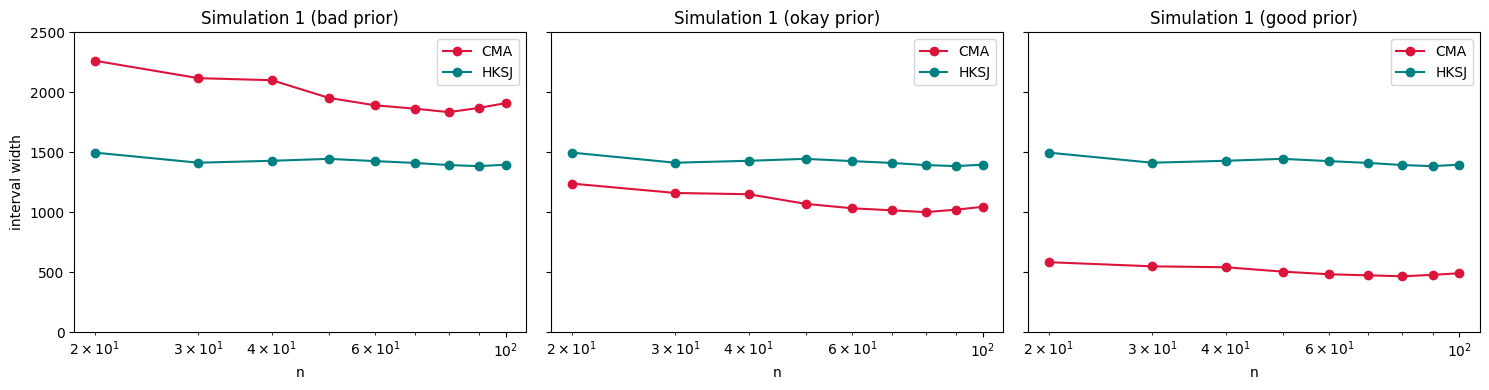

In [5]:
print("Simulation 1")
sim1 = simulation_1()

Simulation 2
No config path provided, using default config
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.2_en1.0_s0 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\4d5af9d2-5b2f-5ace-891c-558010232a3e
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\4d5af9d2-5b2f-5ace-891c-558010232a3e\tasks\ConformalMetaAnalysisTask_08b8805b-267f-5873-bc56-b954f15b6720\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\4d5af9d2-5b2f-5ace-891c-558010232a3e\tasks\ConformalMetaAnalysisTask_08b8805b-267f-5873-bc56-b954f15b6720\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\4d5af9d2-5b2f-5ace-891c-558010232a3e\tasks\ConformalMetaAnalysisTask_08b8805b-267f-5873-bc56-b954f15b6720\samples_cdbbc602-34e2-5a

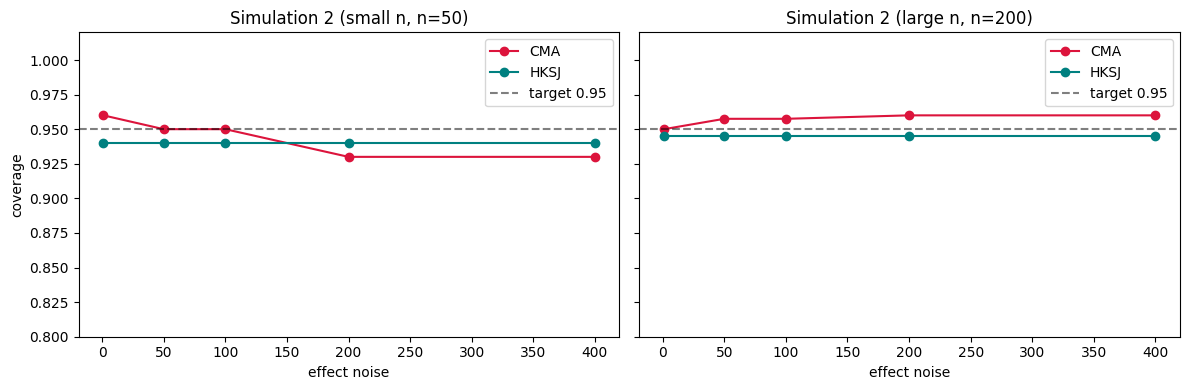

In [5]:
# ---------------------------------------------------------------------
# Simulation 2: Coverage vs effect noise (CMA vs HKSJ)
# ---------------------------------------------------------------------
def simulation_2(
    noise_values=(1.0, 50.0, 100.0, 200.0, 400.0),
    n_values=(50, 200),
    seeds=(0, 1),
    alpha=0.05,
    ylim=(0.80, 1.02),
):
    results = {
        n: {noise: [] for noise in noise_values} for n in n_values
    }
    for n in n_values:
        for noise in noise_values:
            for s in seeds:
                r = run_one(
                    n, prior_error=0.2, effect_noise=noise,
                    alpha=alpha, seed=s,
                )
                results[n][noise].append(r)
                print(
                    f"[Sim2] n={n} noise={noise} seed={s} "
                    f"cma_cov={r['cma_cov']:.3f} hksj_cov={r['hksj_cov']:.3f}"
                )

    fig, axes = plt.subplots(1, len(n_values), figsize=(6 * len(n_values), 4),
                             sharey=True)
    for ax, n in zip(axes, n_values):
        noise_vals = sorted(results[n].keys())
        cma = [
            np.nanmean([r["cma_cov"] for r in results[n][noise]])
            for noise in noise_vals
        ]
        hksj = [
            np.nanmean([r["hksj_cov"] for r in results[n][noise]])
            for noise in noise_vals
        ]
        ax.plot(noise_vals, cma, "-o", label="CMA", color="crimson")
        ax.plot(noise_vals, hksj, "-o", label="HKSJ", color="teal")
        ax.axhline(1 - alpha, ls="--", color="black", alpha=0.5,
                   label=f"target {1 - alpha:.2f}")
        ax.set_xlabel("effect noise")
        size_label = "small n" if n < 100 else "large n"
        ax.set_title(f"Simulation 2 ({size_label}, n={n})")
        ax.set_ylim(*ylim)
        ax.legend()
    axes[0].set_ylabel("coverage")
    plt.tight_layout()
    plt.savefig("simulation_2.png", dpi=150)
    plt.show()
    return results

print("Simulation 2")
sim2 = simulation_2()

Simulation 3
No config path provided, using default config
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.1_en1_s0 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\fb9360fc-9359-563e-bc02-f8e0310d97c3
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\fb9360fc-9359-563e-bc02-f8e0310d97c3\tasks\ConformalMetaAnalysisTask_08b8805b-267f-5873-bc56-b954f15b6720\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\fb9360fc-9359-563e-bc02-f8e0310d97c3\tasks\ConformalMetaAnalysisTask_08b8805b-267f-5873-bc56-b954f15b6720\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\fb9360fc-9359-563e-bc02-f8e0310d97c3\tasks\ConformalMetaAnalysisTask_08b8805b-267f-5873-bc56-b954f15b6720\samples_cdbbc602-34e2-5a41

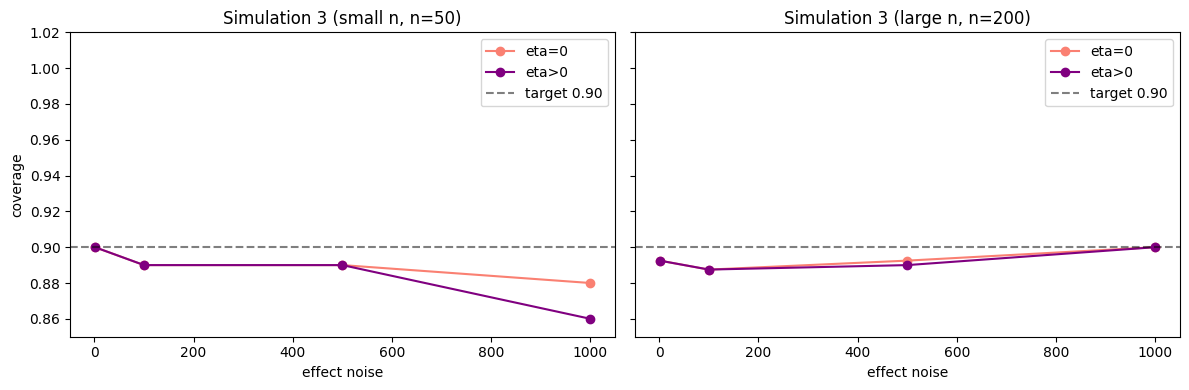

In [7]:
# ---------------------------------------------------------------------
# Simulation 3: Coverage with eta=0 vs eta>0
# ---------------------------------------------------------------------
def simulation_3(
    noise_values=(1, 100.0 , 500.0, 1000.0),
    n_values=(50, 200),
    seeds=(0, 1),
    alpha=0.1,
    ylim=(0.85, 1.02),
):
    # Compute the eta that targets ~2alpha confidence loss: eta = 2*inverfc(1/(2*(1-alpha)))^2
    # Here we just use a modest positive value (0.4015 from the paper).
    eta_values = {"eta=0": 0.0, "eta>0": 0.4015}

    results = {
        n: {name: {noise: [] for noise in noise_values}
            for name in eta_values}
        for n in n_values
    }
    for n in n_values:
        for name, eta in eta_values.items():
            for noise in noise_values:
                for s in seeds:
                    r = run_one(
                        n, prior_error=0.1, effect_noise=noise,
                        alpha=alpha, eta=eta, seed=s,
                    )
                    results[n][name][noise].append(r)
                    print(
                        f"[Sim3] n={n} {name} noise={noise} "
                        f"cov={r['cma_cov']:.3f}"
                    )

    fig, axes = plt.subplots(1, len(n_values), figsize=(6 * len(n_values), 4),
                             sharey=True)
    for ax, n in zip(axes, n_values):
        noise_vals = sorted(noise_values)
        for name, color in [("eta=0", "salmon"), ("eta>0", "purple")]:
            covs = [
                np.nanmean([r["cma_cov"] for r in results[n][name][noise]])
                for noise in noise_vals
            ]
            ax.plot(noise_vals, covs, "-o", label=name, color=color)
        ax.axhline(1 - alpha, ls="--", color="black", alpha=0.5,
                   label=f"target {1 - alpha:.2f}")
        size_label = "small n" if n < 100 else "large n"
        ax.set_xlabel("effect noise")
        ax.set_title(f"Simulation 3 ({size_label}, n={n})")
        ax.set_ylim(*ylim)
        ax.legend()
    axes[0].set_ylabel("coverage")
    plt.tight_layout()
    plt.savefig("simulation_3.png", dpi=150)
    plt.show()
    return results


print("Simulation 3")
sim3 = simulation_3()

Simulation 4
No config path provided, using default config
Fetching PMLB dataset: 1196_BNG_pharynx
Saved PMLB metadata to ./data/pmlb_pe0.0_en0.02_s0\pmlb_meta_analysis_noisy-metadata-pyhealth.csv
Initializing pmlb_1196_BNG_pharynx dataset from ./data/pmlb_pe0.0_en0.02_s0 (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\68929a1e-c1c5-5c4b-abaf-686dd0221621
Setting task ConformalMetaAnalysisTask for pmlb_1196_BNG_pharynx base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\68929a1e-c1c5-5c4b-abaf-686dd0221621\tasks\ConformalMetaAnalysisTask_08b8805b-267f-5873-bc56-b954f15b6720\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\68929a1e-c1c5-5c4b-abaf-686dd0221621\tasks\ConformalMetaAnalysisTask_08b8805b-267f-5873-bc56-b954f15b6720\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\Users\brett\AppData\Local\pyhealth\pyheal

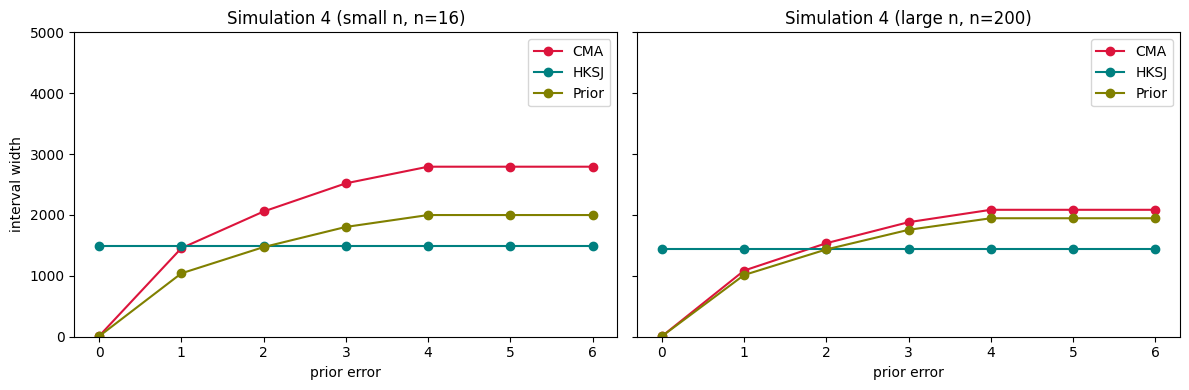

In [8]:
# ---------------------------------------------------------------------
# Simulation 4: Width comparison vs prior quality (CMA vs HKSJ vs Prior)
# ---------------------------------------------------------------------

def simulation_4(
    prior_values=(0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0),
    n_values=(16, 200),
    seeds=(0, 1),
    alpha=0.1,
    ylim=(0, 5000),
):
    results = {
        n: {pe: [] for pe in prior_values} for n in n_values
    }
    for n in n_values:
        for pe in prior_values:
            for s in seeds:
                r = run_one(
                    n, prior_error=pe, effect_noise=0.02,
                    alpha=alpha, seed=s,
                )
                results[n][pe].append(r)
                print(
                    f"[Sim4] n={n} pe={pe} seed={s} "
                    f"cma={r['cma_width']:.1f} "
                    f"hksj={r['hksj_width']:.1f} "
                    f"prior={r['prior_width']:.1f}"
                )

    fig, axes = plt.subplots(1, len(n_values), figsize=(6 * len(n_values), 4),
                             sharey=True)
    for ax, n in zip(axes, n_values):
        pe_vals = sorted(results[n].keys())
        cma = [
            np.nanmean([r["cma_width"] for r in results[n][pe]])
            for pe in pe_vals
        ]
        hksj = [
            np.nanmean([r["hksj_width"] for r in results[n][pe]])
            for pe in pe_vals
        ]
        prior = [
            np.nanmean([r["prior_width"] for r in results[n][pe]])
            for pe in pe_vals
        ]
        ax.plot(pe_vals, cma, "-o", label="CMA", color="crimson")
        ax.plot(pe_vals, hksj, "-o", label="HKSJ", color="teal")
        ax.plot(pe_vals, prior, "-o", label="Prior", color="olive")
        size_label = "small n" if n < 100 else "large n"
        ax.set_xlabel("prior error")
        ax.set_title(f"Simulation 4 ({size_label}, n={n})")
        ax.set_ylim(*ylim)
        ax.legend()
    axes[0].set_ylabel("interval width")
    plt.tight_layout()
    plt.savefig("simulation_4.png", dpi=150)
    plt.show()
    return results

print("Simulation 4")
sim4 = simulation_4()

In [6]:
"""BERT Encoder Ablation for Conformal Meta-Analysis Priors.

Tests whether a domain-specific pretrained language model (PubMedBERT)
produces better priors for CMA than hand-crafted numeric features.

Pipeline:
    1. Load the amiodarone dataset (from your PyHealth dataset)
    2. For each trial, get text = real abstract (if available) or
       generated clinical prose (fallback)
    3. Embed text with PubMedBERT (CLS token, frozen)
    4. Train CMAPriorEncoder on the embeddings
    5. Run CMA on trusted trials using the learned prior
    6. Compare against hand-crafted baseline and HKSJ

Runtime: ~3 min on CPU (first run downloads ~440 MB PubMedBERT weights).

Required:
    pip install transformers torch pdfplumber

File layout:
    ./bert_ablation/
        bert_ablation.py              (this file)
        extract_abstracts.py          (run first)
        amiodarone_abstracts.json     (output of extract_abstracts)
        pdfs/                         (your trial PDFs)
"""

from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from scipy.stats import t as t_dist

from pyhealth.datasets import AmiodaroneTrialDataset
from pyhealth.models.cma_prior_encoder import CMAPriorEncoder
from pyhealth.models.conformal_meta_analysis_krr import (
    ConformalMetaAnalysisModel,
)
from pyhealth.tasks.conformal_meta_analysis import (
    ConformalMetaAnalysisTask,
)


# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------
ABSTRACTS_PATH = Path("./amiodarone_abstracts.json")
DATASET_ROOT = "./data/amiodarone"
PUBMEDBERT = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract"

FEATURE_COLUMNS = [
    "amiodarone_total_24h_mg", "comparison_intensity",
    "af_duration_gt_48h", "outcome_time_gt_48h",
    "mean_age", "mean_la_size",
    "fraction_male", "fraction_cv_disease", "followup_fraction",
    "adequate_concealment", "masked_patients",
    "masked_caregiver", "masked_assessor",
]


# ---------------------------------------------------------------------
# Text rendering (fallback for trials without real abstracts)
# ---------------------------------------------------------------------
def generate_clinical_prose(row: pd.Series) -> str:
    """Render a trial's structured features as clinical prose.

    Used when a real abstract is not available. Output mimics the
    style of a clinical trial abstract so PubMedBERT processes it
    similarly.
    """
    name = row.get("trial_name", "trial")
    dose = row.get("amiodarone_total_24h_mg", 0) or 0
    comp_intensity = int(row.get("comparison_intensity", 0) or 0)
    af_long = bool(row.get("af_duration_gt_48h", 0) or 0)
    outcome_long = bool(row.get("outcome_time_gt_48h", 0) or 0)
    mean_age = row.get("mean_age", 0) or 0
    la_size = row.get("mean_la_size", 0) or 0
    male_frac = row.get("fraction_male", 0) or 0
    cv_frac = row.get("fraction_cv_disease", 0) or 0
    followup = row.get("followup_fraction", 1.0) or 1.0
    masked_pt = bool(row.get("masked_patients", 0) or 0)
    masked_cg = bool(row.get("masked_caregiver", 0) or 0)
    adequate_concealment = bool(row.get("adequate_concealment", 0) or 0)

    comparison = {
        0: "placebo control",
        1: "low-intensity active comparator",
        2: "high-intensity active comparator",
    }.get(comp_intensity, "active comparator")

    af_str = "persistent" if af_long else "recent-onset"
    outcome_str = (
        "long-term conversion (greater than 48 hours)" if outcome_long
        else "short-term conversion (within 48 hours)"
    )
    blinding = (
        "double-blinded" if (masked_pt and masked_cg)
        else "single-blinded" if masked_pt
        else "open-label"
    )

    return (
        f"Randomized controlled trial ({name}) evaluating amiodarone "
        f"versus {comparison} for conversion of atrial fibrillation to "
        f"sinus rhythm. Patients had {af_str} atrial fibrillation. "
        f"Total amiodarone dose over 24 hours: {dose:.0f} mg. "
        f"Outcome assessed as {outcome_str}. "
        f"Mean patient age {mean_age:.0f} years; "
        f"mean left atrial size {la_size:.1f} cm. "
        f"Male fraction {male_frac:.2f}; "
        f"cardiovascular disease prevalence {cv_frac:.2f}. "
        f"Follow-up completion {followup:.2f}. "
        f"Study was {blinding} with "
        f"{'adequate' if adequate_concealment else 'unclear'} "
        f"allocation concealment."
    )


def get_trial_text(row: pd.Series, abstracts: Dict[str, str]) -> tuple:
    """Return (text, source) where source is 'real' or 'generated'."""
    name = row.get("trial_name", "")
    real = abstracts.get(name, "").strip() if name else ""
    if real and len(real) > 100:
        return real, "real"
    return generate_clinical_prose(row), "generated"


# ---------------------------------------------------------------------
# Embed with PubMedBERT
# ---------------------------------------------------------------------
def embed_with_bert(
    texts: List[str], model_name: str = PUBMEDBERT, device: str = "cpu"
) -> torch.Tensor:
    """Return [n, 768] CLS embeddings, one per text."""
    from transformers import AutoTokenizer, AutoModel

    print(f"Loading {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    model.eval()

    all_emb = []
    with torch.no_grad():
        for i, text in enumerate(texts):
            inputs = tokenizer(
                text, padding=True, truncation=True,
                max_length=512, return_tensors="pt",
            ).to(device)
            out = model(**inputs)
            cls = out.last_hidden_state[:, 0, :].squeeze(0).cpu()
            all_emb.append(cls)
            if (i + 1) % 5 == 0:
                print(f"  embedded {i + 1}/{len(texts)}")

    del model, tokenizer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return torch.stack(all_emb)


# ---------------------------------------------------------------------
# HKSJ baseline
# ---------------------------------------------------------------------
def hksj_interval(Y: np.ndarray, V: np.ndarray, alpha: float = 0.1) -> tuple:
    """Hartung-Knapp-Sidik-Jonkman prediction interval."""
    n = len(Y)
    nu = 0.0
    for _ in range(1000):
        w = 1.0 / (V + nu)
        ate = np.sum(w * Y) / np.sum(w)
        nu_new = max(
            0.0,
            np.sum(w ** 2 * ((Y - ate) ** 2 - V)) / np.sum(w ** 2)
            + 1.0 / np.sum(w),
        )
        if abs(nu_new - nu) < 1e-8:
            break
        nu = nu_new
    w = 1.0 / (V + nu)
    ate = np.sum(w * Y) / np.sum(w)
    var_ate = np.sum((Y - ate) ** 2 * w) / ((n - 1) * np.sum(w))
    half = t_dist.ppf(1 - alpha / 2, df=n - 1) * np.sqrt(nu + var_ate)
    return float(ate - half), float(ate + half)


# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
def collect_batch(sample_dataset) -> Dict[str, torch.Tensor]:
    """Stack all samples in a SampleDataset into a single batch dict."""
    samples = list(sample_dataset)
    batch = {}
    for key in samples[0]:
        vals = [s[key] for s in samples]
        if isinstance(vals[0], torch.Tensor):
            batch[key] = torch.stack(vals).float()
        else:
            try:
                batch[key] = torch.tensor(
                    [float(v) for v in vals], dtype=torch.float32
                ).unsqueeze(-1)
            except (TypeError, ValueError):
                batch[key] = vals
    return batch


def train_encoder(encoder, features, targets, epochs=500, lr=1e-3):
    """Train the MLP head on a fixed batch (frozen BERT upstream)."""
    opt = optim.Adam(encoder.parameters(), lr=lr)
    targets = targets.view(-1, 1).float()
    encoder.train()
    for _ in range(epochs):
        opt.zero_grad()
        out = encoder(features=features, true_effect=targets)
        out["loss"].backward()
        opt.step()
    encoder.eval()
    return encoder


class _FeatureDataset:
    """Minimal SampleDataset-like wrapper for CMAPriorEncoder init."""

    def __init__(self, features: torch.Tensor, targets: torch.Tensor):
        self._feats = features
        self._tgts = targets.view(-1)
        self.input_schema = {"features": "tensor"}
        self.output_schema = {"true_effect": "regression"}

    def __len__(self):
        return len(self._feats)

    def __getitem__(self, i):
        return {
            "features": self._feats[i].float(),
            "true_effect": float(self._tgts[i]),
        }


# ---------------------------------------------------------------------
# Core: run CMA with a given feature representation
# ---------------------------------------------------------------------
def run_cma_with_features(
    u_features: torch.Tensor,
    t_features: torch.Tensor,
    u_batch: Dict[str, torch.Tensor],
    t_batch: Dict[str, torch.Tensor],
    trusted_dataset,
    label: str,
    input_desc: str,
    hidden_dims: List[int] = [64, 32],
    embed_dim: int = 16,
    alpha: float = 0.1,
) -> Dict:
    """Train encoder on u_features, run CMA on trusted, return metrics."""
    fake_u = _FeatureDataset(u_features, u_batch["true_effect"])

    encoder = CMAPriorEncoder(
        dataset=fake_u, hidden_dims=hidden_dims, embed_dim=embed_dim,
    )
    train_encoder(
        encoder,
        features=u_features.float(),
        targets=u_batch["true_effect"],
    )

    # Predict M for trusted trials
    M = encoder.predict_prior_mean(t_features.float())
    t_with_prior = dict(t_batch)
    t_with_prior["prior_mean"] = M.unsqueeze(-1)

    # Run CMA (uses the ORIGINAL 13-d features for the kernel; BERT
    # only drives the prior mean — this isolates prior-quality effect)
    cma = ConformalMetaAnalysisModel(dataset=trusted_dataset, alpha=alpha)
    with torch.no_grad():
        out = cma(**t_with_prior)

    lo = out["interval_lower"].cpu().numpy().ravel()
    hi = out["interval_upper"].cpu().numpy().ravel()
    u_true = t_batch["true_effect"].cpu().numpy().ravel()

    finite = np.isfinite(lo) & np.isfinite(hi)
    width = (
        float(np.mean(hi[finite] - lo[finite])) if finite.any() else np.nan
    )
    coverage = float(np.mean((u_true >= lo) & (u_true <= hi)))
    mse_prior = float(
        torch.mean((M - t_batch["true_effect"].squeeze(-1)) ** 2)
    )

    return {
        "Encoder": label,
        "Input": input_desc,
        "Feature Dim": u_features.shape[1],
        "Prior MSE": round(mse_prior, 4),
        "CMA Width": round(width, 4),
        "CMA Coverage": round(coverage, 3),
    }


# ---------------------------------------------------------------------
# Main ablation
# ---------------------------------------------------------------------
def run_bert_ablation(seed: int = 0, alpha: float = 0.1) -> pd.DataFrame:
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Load abstracts (empty dict if file not present)
    if ABSTRACTS_PATH.exists():
        abstracts = json.loads(ABSTRACTS_PATH.read_text(encoding='utf-8'))
    else:
        print(f"[INFO] {ABSTRACTS_PATH} not found — using generated prose "
              f"for all trials. Run extract_abstracts.py first to use "
              f"real PDFs.")
        abstracts = {}

    # Load dataset & build lookup
    dataset = AmiodaroneTrialDataset(root=DATASET_ROOT)
    csv_path = os.path.join(
        DATASET_ROOT, "amiodarone_trials-metadata-pyhealth.csv"
    )
    df = pd.read_csv(csv_path)

    # Build text inputs
    texts: List[str] = []
    n_real, n_generated = 0, 0
    for _, row in df.iterrows():
        text, source = get_trial_text(row, abstracts)
        texts.append(text)
        if source == "real":
            n_real += 1
        else:
            n_generated += 1

    print(f"\nText inputs: {n_real} real abstracts, "
          f"{n_generated} generated prose, {len(df)} total\n")

    # Align indices to splits
    untrusted_idx = df.index[df["split"] == "untrusted"].tolist()
    trusted_idx = df.index[df["split"] == "trusted"].tolist()

    # Hand-crafted baseline via your existing task pipeline
    task_u = ConformalMetaAnalysisTask(
        target_column="log_relative_risk",
        feature_columns=FEATURE_COLUMNS,
        split_column="split", split_value="untrusted",
        observed_column=None, variance_column=None, prior_column=None,
        input_schema={"features": "tensor"},
    )
    untrusted = dataset.set_task(task_u)
    u_batch = collect_batch(untrusted)

    task_t = ConformalMetaAnalysisTask(
    target_column="log_relative_risk",
    feature_columns=FEATURE_COLUMNS,
    split_column="split", split_value="trusted",
    observed_column="log_relative_risk",
    variance_column="variance",
    prior_column=None,
    input_schema={
        "features": "tensor",
        "observed_effect": "tensor",
        "variance": "tensor",
    },
)
    trusted = dataset.set_task(task_t)
    t_batch = collect_batch(trusted)

    rows = []

    # ---- Row 1: hand-crafted 13 features (baseline) ----
    print("Running hand-crafted baseline...")
    rows.append(run_cma_with_features(
        u_features=u_batch["features"],
        t_features=t_batch["features"],
        u_batch=u_batch, t_batch=t_batch,
        trusted_dataset=trusted,
        label="MLP",
        input_desc="13 hand-crafted features",
        alpha=alpha,
    ))

    # ---- Embed all 21 trials with PubMedBERT ----
    print("\nEmbedding trials with PubMedBERT...")
    bert_emb = embed_with_bert(texts, PUBMEDBERT)
    print(f"BERT embeddings shape: {bert_emb.shape}\n")

    u_bert = bert_emb[untrusted_idx]
    t_bert = bert_emb[trusted_idx]

    # ---- Row 2: PubMedBERT with default MLP head ----
    print("Running PubMedBERT + default MLP...")
    rows.append(run_cma_with_features(
        u_features=u_bert, t_features=t_bert,
        u_batch=u_batch, t_batch=t_batch,
        trusted_dataset=trusted,
        label="PubMedBERT + MLP",
        input_desc=f"{n_real} real / {n_generated} gen",
        hidden_dims=[64, 32], embed_dim=16,
        alpha=alpha,
    ))

    # ---- Rows 3-4: PubMedBERT with different MLP head sizes ----
    for arch_name, hd, ed in [
        ("Shallow", [32], 8),
        ("Deep", [128, 64], 16),
    ]:
        print(f"Running PubMedBERT + {arch_name} MLP...")
        rows.append(run_cma_with_features(
            u_features=u_bert, t_features=t_bert,
            u_batch=u_batch, t_batch=t_batch,
            trusted_dataset=trusted,
            label=f"PubMedBERT + {arch_name}",
            input_desc=f"{n_real} real / {n_generated} gen",
            hidden_dims=hd, embed_dim=ed,
            alpha=alpha,
        ))

    # ---- Final row: HKSJ baseline ----
    Y = t_batch["observed_effect"].cpu().numpy().ravel()
    V = t_batch["variance"].cpu().numpy().ravel()
    u_true = t_batch["true_effect"].cpu().numpy().ravel()
    hlo, hhi = hksj_interval(Y, V, alpha=alpha)
    hksj_cov = float(np.mean((u_true >= hlo) & (u_true <= hhi)))
    rows.append({
        "Encoder": "HKSJ (baseline)",
        "Input": "—",
        "Feature Dim": 0,
        "Prior MSE": np.nan,
        "CMA Width": round(hhi - hlo, 4),
        "CMA Coverage": round(hksj_cov, 3),
    })

    return pd.DataFrame(rows)


if __name__ == "__main__":
    print("=" * 80)
    print("BERT Encoder Ablation for Conformal Meta-Analysis")
    print("=" * 80)

    results = run_bert_ablation()

    print("\n" + "=" * 80)
    print("Results")
    print("=" * 80)
    print(results.to_string(index=False))

    # Save for the report
    results.to_csv("bert_ablation_results.csv", index=False)
    print("\nSaved bert_ablation_results.csv")


BERT Encoder Ablation for Conformal Meta-Analysis
No config path provided, using default config
Saved amiodarone trial metadata to ./data/amiodarone\amiodarone_trials-metadata-pyhealth.csv
Initializing amiodarone_trials dataset from ./data/amiodarone (dev mode: False)
No cache_dir provided. Using default cache dir: C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\0c12f457-48aa-5323-8fe3-37073ca87371

Text inputs: 11 real abstracts, 10 generated prose, 21 total

Setting task ConformalMetaAnalysisTask for amiodarone_trials base dataset...
Task cache paths: task_df=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\0c12f457-48aa-5323-8fe3-37073ca87371\tasks\ConformalMetaAnalysisTask_16d29593-df22-53a0-a938-3dc95faa5399\task_df.ld, samples=C:\Users\brett\AppData\Local\pyhealth\pyhealth\Cache\0c12f457-48aa-5323-8fe3-37073ca87371\tasks\ConformalMetaAnalysisTask_16d29593-df22-53a0-a938-3dc95faa5399\samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at C:\User